<h2 style="text-align: center;">НАЦИОНАЛЬНЫЙ ИССЛЕДОВАТЕЛЬСКИЙ УНИВЕРСИТЕТ 
<br/>МОСКОВСКИЙ ЭНЕРГЕТИЧЕСКИЙ ИНСТИТУТ</h2>
</br>
<h3 style="text-align: center;">Кафедра Паровых и Газовых Турбин</h3>

</br>
</br>
</br>
</br>
</br>

<h1 style="text-align: center;">Курсовая работа по курсу:</h1>
<h1 style="text-align: center;">«Паровые и газовые турбины»</h1>

</br>
</br>
</br>
</br>
</br>

<h5 style="text-align: right;">Студент: Салабай Валерий Романович</h5>
<h5 style="text-align: right;">Группа: ФПэ-01-22</h5>

</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>

<h5 style="text-align: center;">Москва 2025</h5>

## Вариант №8

### $\space$ Дано:
* $P_0 = 24,5\space МПа $ - Давление на входе в турбину
* $t_0 = 550 ^\circ C$ -  Температура на входе в турбину
* $P_{пп} = 4 \space МПа$ -  Давление промежуточного перегрева
* $t_{пп} = 550 ^\circ C$ -  Температура промежуточного перегрева
* $P_{к} = 3,1 \space кПа$ -  Давление в конденсаторе
* $t_{п.в.} = 278^\circ C$ -  Температура питательной воды

* $N_{э} = 570 \space МВт$ -  Электрическая мощность ПТУ
* Z = 8 -  Количество отборов

In [57]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1. Построение процесса расширения пара в турбине. Определение расходов пара на входе в турбину $G_0$ и в конденсатор $G_к$.

In [59]:
import stproverka1 as srd
import graphics as gr

In [60]:
# Константы единиц измерения
MPa = 10 ** 6
kPa = 10 ** 3
MW = 10 ** 6

In [61]:
def create_turbine_model():
    return srd.Steam_Rashod(
        p_o=24.5 * MPa,
        t_o=550, 
        p_nn=4 * MPa, 
        t_nn=550,
        p_k=3.1 * kPa,
        effect_oi=0.85,
        effect_mex=0.9925,
        effect_eg=0.985,
        n=570 * MW,
        t_nv=278
    )

def calculate_steam_flows(turbine):
    return turbine.calc_rashod()

def print_results(g0, gk):
    print(f"Расход свежего пара перед турбиной G_o = {g0:.2f} кг/с")
    print(f"Расход пара в конденсаторе G_k = {gk:.2f} кг/с")


turbine = create_turbine_model()
g0, gk = calculate_steam_flows(turbine)
print_results(g0, gk)

Расход свежего пара перед турбиной G_o = 474.98 кг/с
Расход пара в конденсаторе G_k = 315.57 кг/с


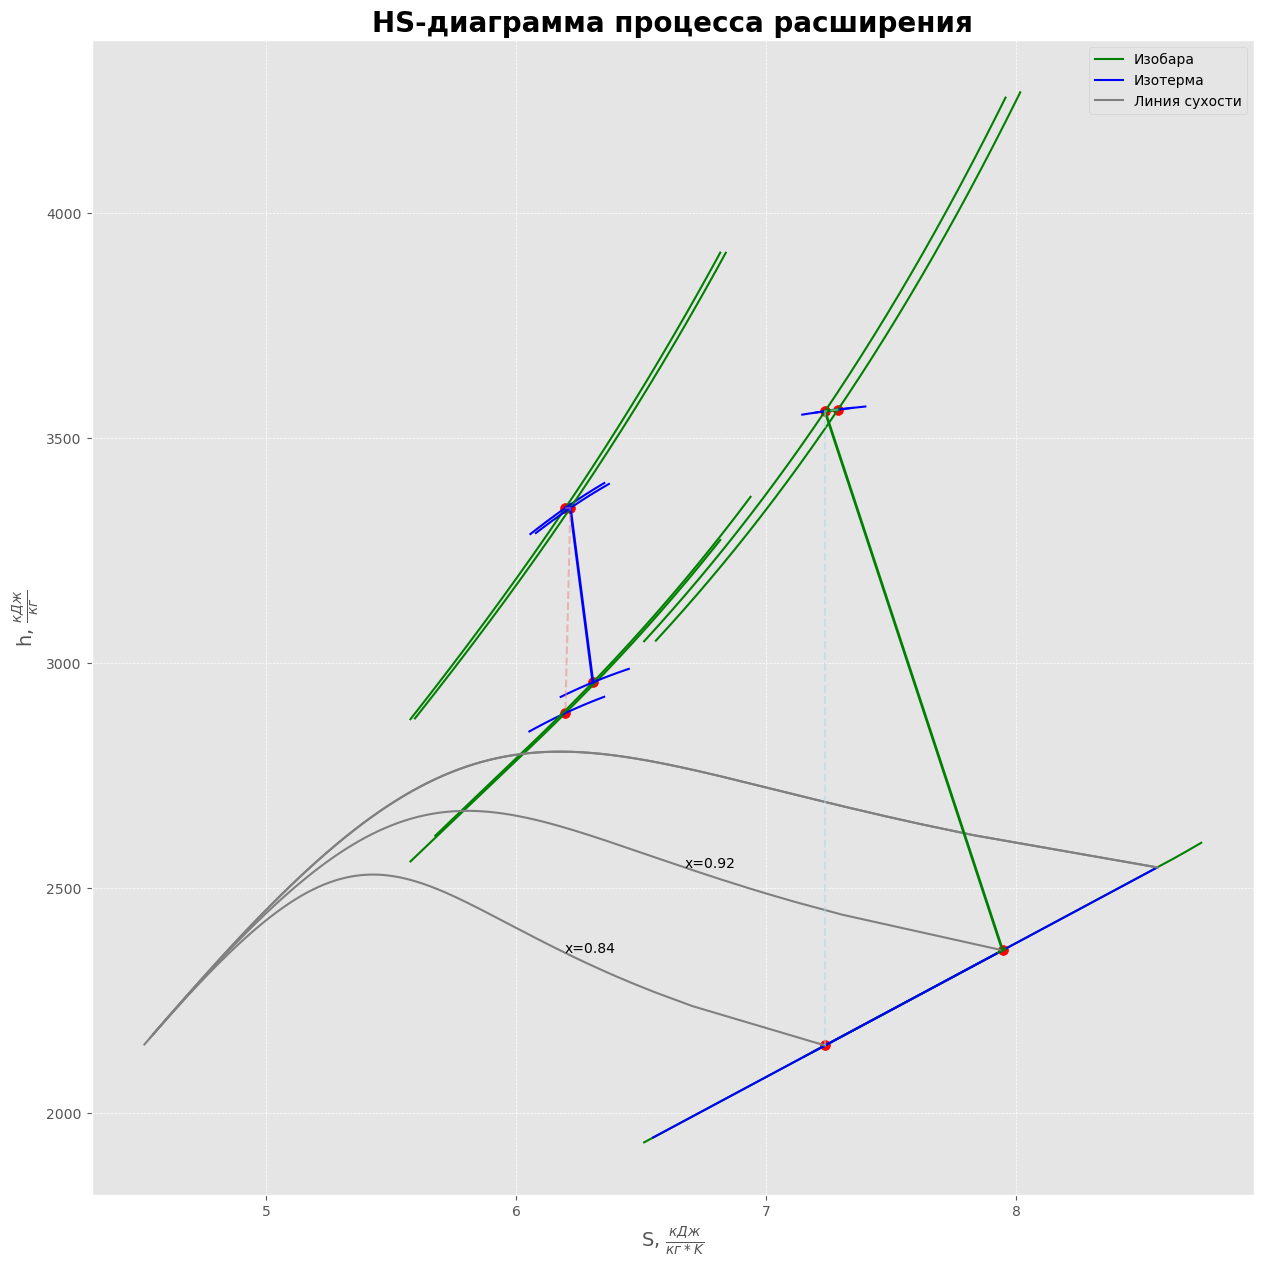

In [62]:
import matplotlib.pyplot as plt
from typing import List

def configure_plot_style():
    """Стиль графиков"""
    plt.style.use('ggplot')

def create_figure():
    return plt.subplots(1, 1, figsize=(15, 15))

def get_process_points(turbine):
    """Возвращает списки точек для всех процессов"""
    return [
        [turbine.point_o_teor, turbine.point_o, turbine.point_1],
        [turbine.point_nn_teor, turbine.point_nn, turbine.point_k],
        [turbine.point_o_teor, turbine.point_o, turbine.point_1_teor], 
        [turbine.point_nn_teor, turbine.point_nn, turbine.point_k_teor]
    ]

def plot_diagram(ax, turbine):
    """Строит HS-диаграмму с процессами"""
    # Все точки для диаграммы
    all_points = [
        turbine.point_o_teor, turbine.point_o, turbine.point_1_teor, turbine.point_1,
        turbine.point_nn_teor, turbine.point_nn, turbine.point_k, turbine.point_k_teor
    ]
    
    # Построение диаграммы
    gr.plot_hs_diagram(ax, points=all_points)
    
    # Параметры для каждого процесса
    processes = get_process_points(turbine)
    styles = [
        {'color': 'blue', 'linestyle': '-', 'linewidth': 2},
        {'color': 'green', 'linestyle': '-', 'linewidth': 2},
        {'color': 'lightcoral', 'linestyle': '--', 'alpha': 0.5},
        {'color': 'lightblue', 'linestyle': '--', 'alpha': 0.5}
    ]
    
    # Построение всех процессов
    for points, style in zip(processes, styles):
        gr.plot_process(ax, points=points, **style)

def configure_axes(ax):
    """Оформление осей"""
    ax.set_title('HS-диаграмма процесса расширения', 
                fontsize=20, 
                fontweight='bold')
    ax.grid(True, which='both', 
           linestyle='--', 
           linewidth=0.5)

def build_hs_diagram(turbine):
    """Основная функция построения диаграммы"""
    configure_plot_style()
    fig, ax = create_figure()
    plot_diagram(ax, turbine)
    configure_axes(ax)
    plt.show()
    
build_hs_diagram(turbine)

# Задание 2: Проведение расчета регулирующей ступени и определение зависимости $η_о$$_л$ от $U/$$с_ф$. Диапазон варьируемого диаметра. Обоснованно выбрать вариант исполнения регулирующей ступени для проектирования ЦВД в рамках заданного диапазона

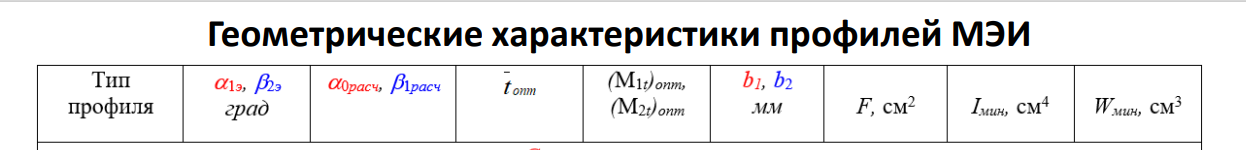

# Сопловая решетка

# Рабочая решетка

In [71]:
from watersteam import WaterSteam
import numpy as np
import determination_of_turbine_parameters as tr
import matplotlib.pyplot as plt 

import pandas as pd

# Поиск оптимального теплоперепада

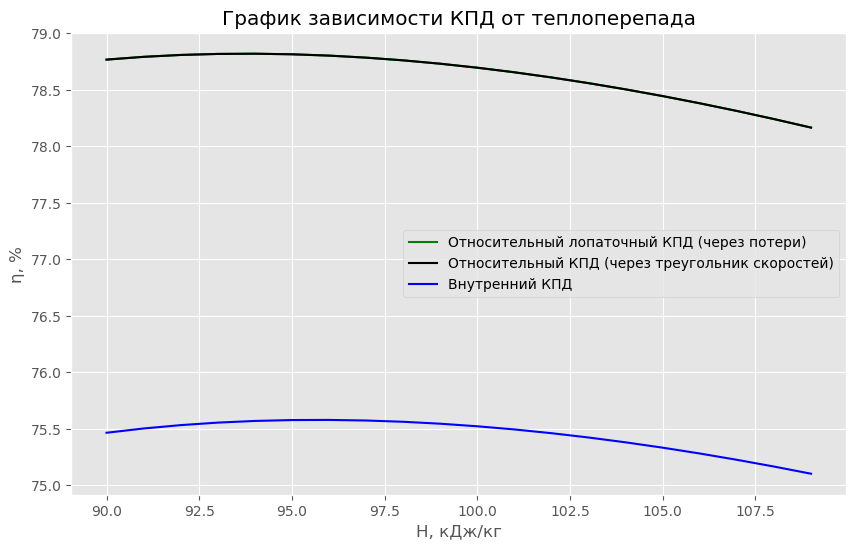

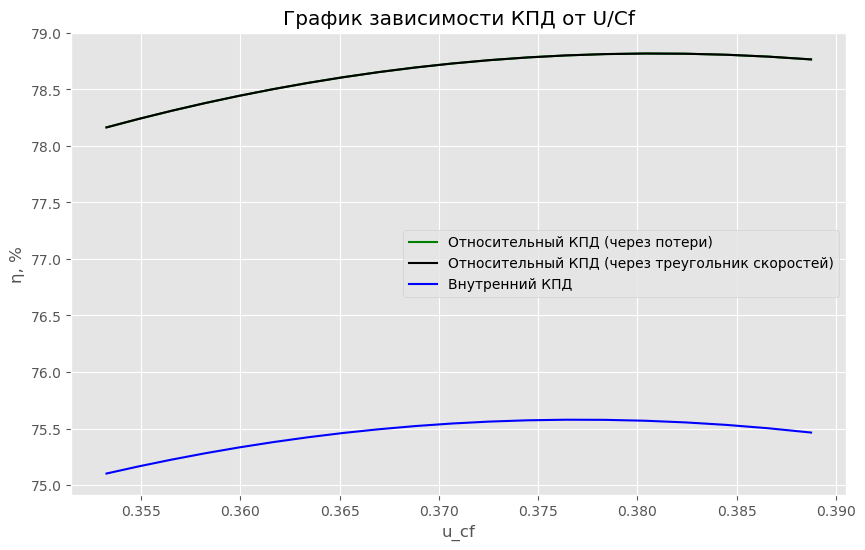

(None,)

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple

def initialize_parameters() -> Tuple[List[float], List[float], List[float], List[float]]:
    """Инициализирует пустые массивы для хранения результатов"""
    return [], [], [], []

def calculate_turbine_parameters(turbine: object, g_0: float, H_values: np.ndarray) -> Tuple[
    List[float], List[float], List[float], List[float], np.ndarray]:
    """
    Выполняет расчет параметров турбины для диапазона теплоперепадов
    Возвращает:
        efficiency_loss, efficiency_velocity, efficiency_internal, u_cf, H_values
    """
    efficiency_loss, efficiency_velocity, efficiency_internal, u_cf = initialize_parameters()
    
    for H in H_values:
        lop = tr.RegularTurbin(
            tochka_o=turbine.point_o,
            n=50,
            d=1.05,
            H_o=H,
            ro=0.12,
            G=g0,
            k=1.33
        )
        lop.calc_sopl_lop(b_1=52, alpha_1_e=17, t_1opt=0.7)
        lop.calc_for_find_koef_rab_lop(pere=0.003)
        lop.calc_rab_lop(b_2=29.8, t_opt_2=0.4)
        
        eff_ol_loss, eff_ol_velocity = lop.calc_eff(xi_vs=0)
        N_i, kpd_oi = lop.calc_int_power(z=10, i=4)
        
        efficiency_loss.append(eff_ol_loss * 100)
        efficiency_velocity.append(eff_ol_velocity * 100)
        efficiency_internal.append(kpd_oi * 100)
        u_cf.append(lop.u_c_f)
    
    return efficiency_loss, efficiency_velocity, efficiency_internal, u_cf, H_values

def plot_efficiency_vs_heat_drop(H: np.ndarray, 
                               efficiency_loss: List[float],
                               efficiency_velocity: List[float],
                               efficiency_internal: List[float]) -> None:
    """Строит график зависимости КПД от теплоперепада"""
    plt.figure(figsize=(10, 6))
    plt.title("График зависимости КПД от теплоперепада")
    plt.xlabel("H, кДж/кг")
    plt.ylabel("η, %")
    
    plt.plot(H, efficiency_loss, color="green", 
            label="Относительный лопаточный КПД (через потери)")
    plt.plot(H, efficiency_velocity, color="black",
            label="Относительный КПД (через треугольник скоростей)")
    plt.plot(H, efficiency_internal, color="blue",
            label="Внутренний КПД")
    
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_efficiency_vs_velocity_ratio(u_cf: List[float],
                                    efficiency_loss: List[float],
                                    efficiency_velocity: List[float],
                                    efficiency_internal: List[float]) -> None:
    """График зависимости КПД от соотношения скоростей"""
    plt.figure(figsize=(10, 6))
    plt.title("График зависимости КПД от U/Cf")
    plt.xlabel("u_cf")
    plt.ylabel("η, %")
    
    plt.plot(u_cf, efficiency_loss, color="green",
            label="Относительный КПД (через потери)")
    plt.plot(u_cf, efficiency_velocity, color="black",
            label="Относительный КПД (через треугольник скоростей)")
    plt.plot(u_cf, efficiency_internal, color="blue",
            label="Внутренний КПД")
    
    plt.grid(True)
    plt.legend()
    plt.show()

def analyze_turbine_performance(turbine: object, g_0: float) -> None:
    H_values = np.arange(90, 110, 1)
    
    # Расчет параметров
    eff_loss, eff_velocity, eff_internal, u_cf, H = calculate_turbine_parameters(
        turbine, g_0, H_values
    )
    
    # Построение графиков
    plot_efficiency_vs_heat_drop(H, eff_loss, eff_velocity, eff_internal)
    plot_efficiency_vs_velocity_ratio(u_cf, eff_loss, eff_velocity, eff_internal)


analyze_turbine_performance(turbine, g0) ,


In [76]:
 def find_optimal_heat_drop(turbine: object, g0: float, H_range: np.ndarray = np.arange(90, 110, 1)) -> float:
   
    eff_loss, eff_velocity, eff_internal, u_cf, H_values = calculate_turbine_parameters(
        turbine, g0, H_range
    )
      
    optimal_idx = np.argmax(eff_internal)
    optimal_H = H_values[optimal_idx]
     
    return optimal_H


optimal_H = find_optimal_heat_drop(turbine, g0)
print(f"Оптимальный теплоперепад: {optimal_H} кДж/кг")

Оптимальный теплоперепад: 96 кДж/кг


In [77]:
lop = tr.RegularTurbin(tochka_o = turbine.point_o, 
                    n = 50,
                       d = 1.05,
                        H_o =96, 
                         ro = 0.12,
                          G = g0, 
                           k = 1.33)
fi, mu = lop.calc_sopl_lop(b_1 =  52 , alpha_1_e = 17 , t_1opt = 0.7)
m_2_pred, delt_H_c, H_oc, zit_sum, mu_1 = lop.calc_for_find_koef_rab_lop(pere = 0.003)
lop.calc_rab_lop(b_2 = 29.8 , t_opt_2 = 0.4)
eff_oi_loss, eff_oi_velocity =lop.calc_eff(xi_vs = 0)
N_i,efficiency_internal = lop.calc_int_power(z= 10, i =4)
sigma_bend, sigma_streth, b_2 = lop.calc_stength(W_atl = 0.39 ,b_2_atl = 25.6 ,sigma_bend_dop = 20 )
table_v_d,table_loss, table_points, table_par = lop.tabl()
tochka_1_t, tochka_1, tochka_2_t, tochka_2, tochka_0 = lop.points()
lop.M_1_t
m_2_pred

0.46843083825734966

# Значения потерь

In [79]:
table_loss

,"Потери, %"
,
В сопловой решетке,1.908
В рабочей решетке,5.453
Энергия выходной скорости,13.839
Абсолютные потери от утечек через периферийное уплотнение ступени,1.353
Абсолютные потери от трения диска,0.204
Абсолютные потери от парциальности,1.666


# Параметры сопловой и рабочей решетки

In [81]:
table_par

,"Длины лопаток, м","Число лопаток, шт"
,,
Cопловая решетка,0.025,78.0
Рабочая решетка,0.028,278.0


# Значения КПД, напряжений и мощности

In [83]:
'''Выводмм результаты расчетов'''
print(f"Внутренняя мощность ступени N_i: {np.round(N_i,3)} кВт")
print(f"Изгибающие напряжения σ_и: {np.round(sigma_bend,3)} МПа")
print(f"Напряжение растяжения в корневом сечении рабочей лопатки σ_р: {np.round(sigma_streth,3)} МПа")
print(f"Относительный лопаточный КПД полученный через потери : {np.round(eff_oi_loss * 100,3)} %")
print(f"Относительный лопаточный КПД полученный через треугольник скоростей : {np.round(eff_oi_velocity * 100,3)} %")
print(f"Внутренний относительный КПД  : {np.round(efficiency_internal * 100,3)} %")

Внутренняя мощность ступени N_i: 34461.892 кВт
Изгибающие напряжения σ_и: 20.713 МПа
Напряжение растяжения в корневом сечении рабочей лопатки σ_р: 11.172 МПа
Относительный лопаточный КПД полученный через потери : 78.8 %
Относительный лопаточный КПД полученный через треугольник скоростей : 78.8 %
Внутренний относительный КПД  : 75.578 %


# Процесс расширения ступени

,"P, МПа","T, К, °","h, кДж/кг","s,кДж/(кг*К)"
,,,,
Параметры перед ступенью,23.275,818.661,3345.098,6.217
Теоретичекие параметры за сопловой решеткой,17.722,768.985,3260.618,6.217
Параметры за сопловой решеткой,17.722,769.571,3262.450,6.219
Теоретичекие параметры за ступенью,17.054,762.785,3250.930,6.219
Параметры за ступенью,17.054,764.467,3256.164,6.226


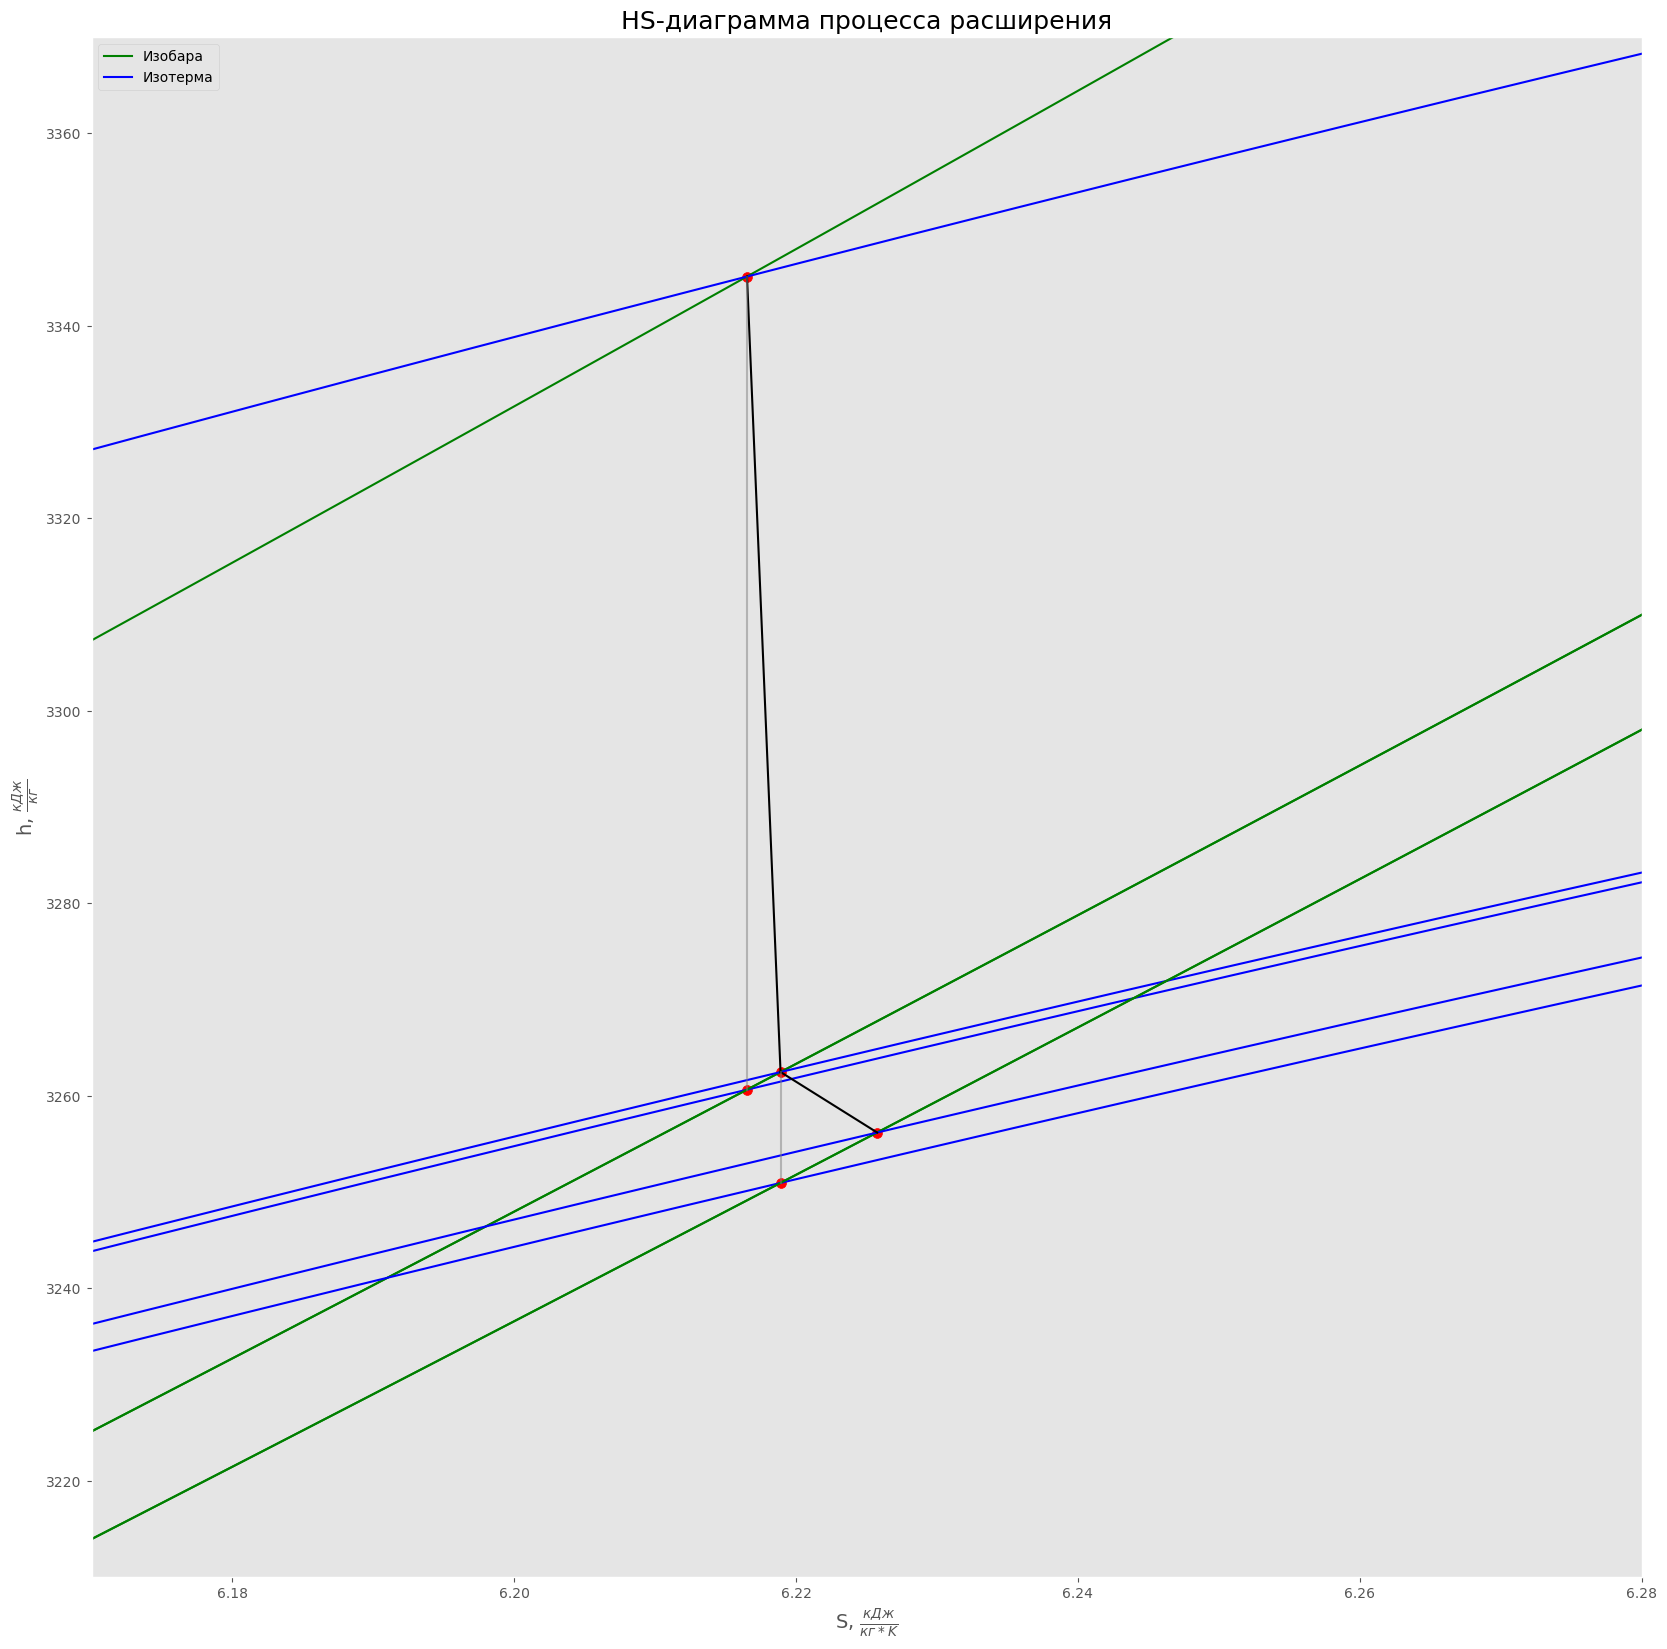

In [85]:
def setup_hs_diagram():
    """Инициализирует график HS-диаграммы"""
    fig, ax = gr.plt.subplots(1, 1, figsize=(20, 20))
    ax.set_xlim(6.17, 6.28)
    ax.set_ylim(3210, 3370)
    return fig, ax

def plot_hs_points(ax, points):
    """Отображает точки на HS-диаграмме"""
    gr.plot_hs_diagram(ax, points=points)

def plot_process_lines(ax, points_real, points_theoretical):
    """Рисует линии процессов"""
    # Реальные процессы
    gr.plot_process(ax, points=points_real[0], color='black')
    gr.plot_process(ax, points=points_real[1], color='black')
    
    # Теоретические процессы
    gr.plot_process(ax, points=points_theoretical[0], alpha=0.5, color='grey')
    gr.plot_process(ax, points=points_theoretical[1], alpha=0.5, color='grey')

def create_hs_plot(turbine, tochka_1_t, tochka_1, tochka_2_t, tochka_2):
    """Создает полную HS-диаграмму"""
    fig, ax = setup_hs_diagram()
    
    # Все точки процесса
    all_points = [turbine.point_o, tochka_1_t, tochka_1, tochka_2_t, tochka_2]
    
    # Линии процессов
    real_processes = [
        [turbine.point_o, tochka_1],
        [tochka_1, tochka_2]
    ]
    theoretical_processes = [
        [turbine.point_o, tochka_1_t],
        [tochka_1, tochka_2_t]
    ]
    
    plot_hs_points(ax, all_points)
    plot_process_lines(ax, real_processes, theoretical_processes)
    
    return table_points  
    

result = create_hs_plot(turbine, tochka_1_t, tochka_1, tochka_2_t, tochka_2)
table_points


# Треугольник скоростей

,"Абсолютная скорость (с), м/с","Абсолютный угол (α) , °","Относительная скорость выхода (w) , м/с","Относительный угол (β) , °"
,,,,
За сопловой решеткой,406.568,16.688,253.052,27.475
За рабочей решеткой,163.008,65.000,276.777,32.224


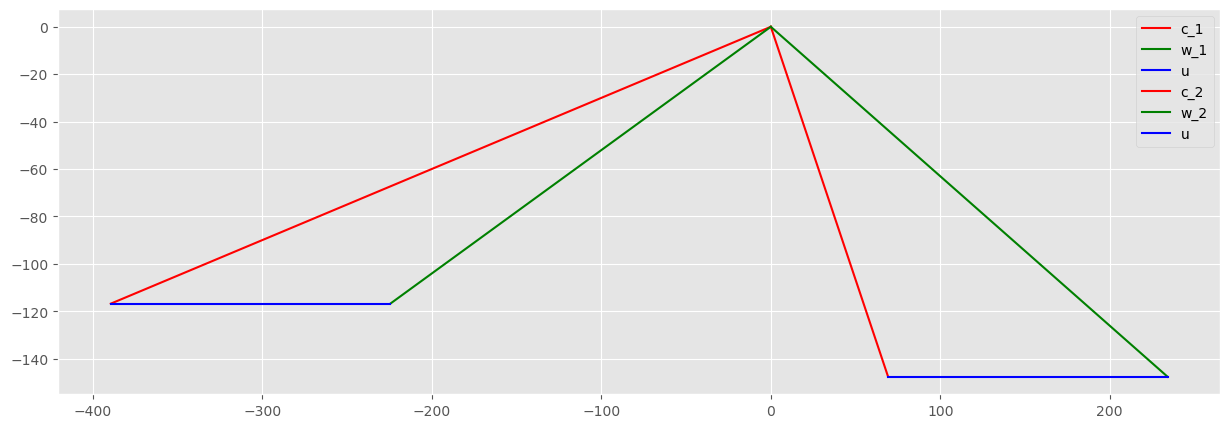

In [111]:
lop.triangle()
table_v_d

# Задание 3: Определение числа ступеней и распределение параметров по ним.

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import ssteps as steps

In [90]:
# Параметры точки 0
print(f"P_o= {tochka_0.find_p()}, МПа")  
print(f"h_o= {tochka_0.find_h()}, кДж/кг")  

P_o= 17.053919399995042, МПа
h_o= 3272.543621175134, кДж/кг


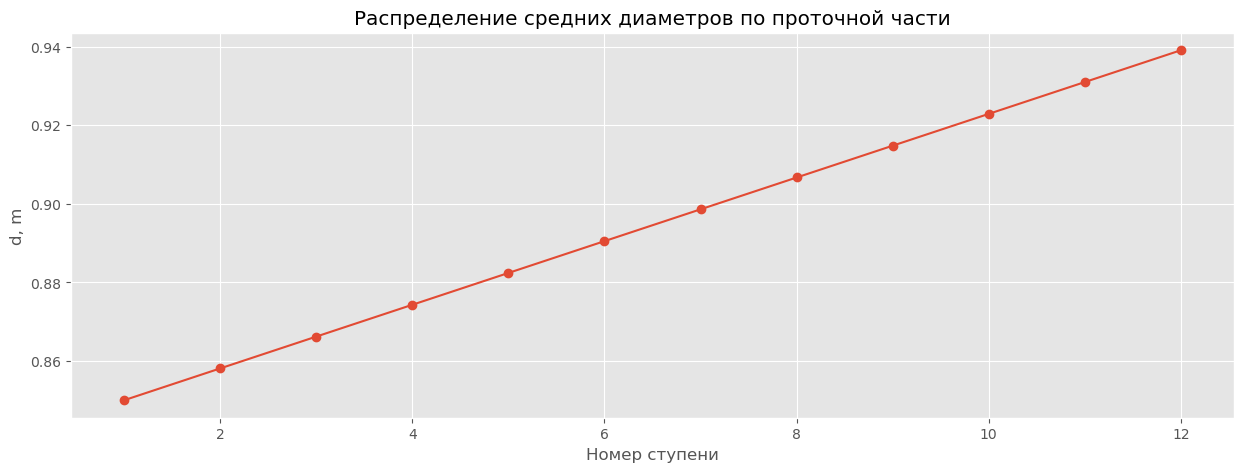

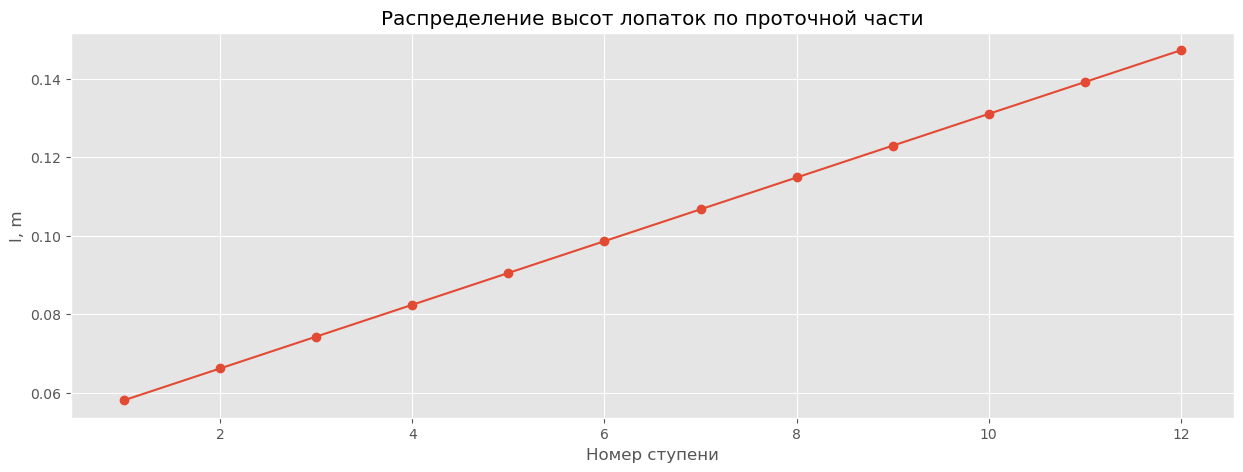

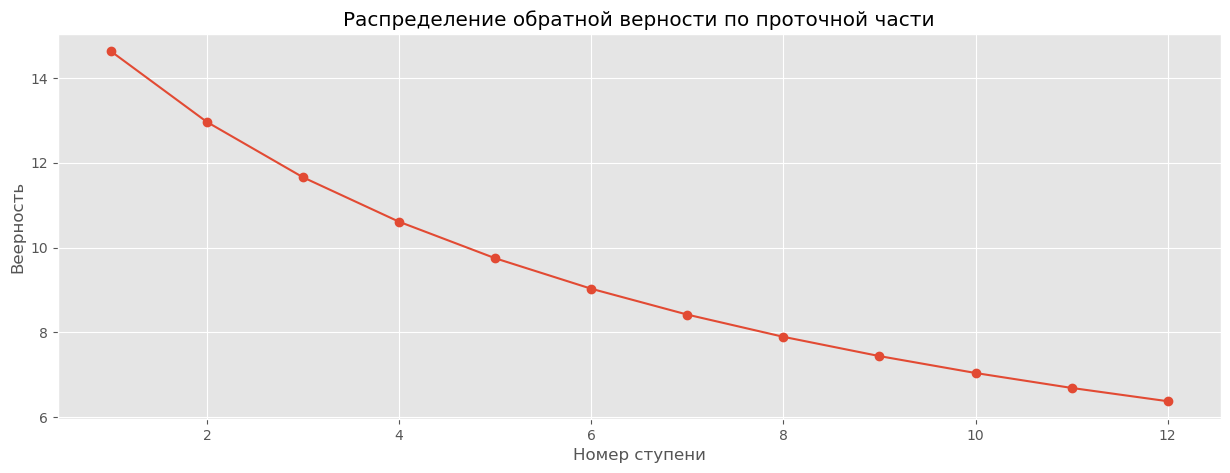

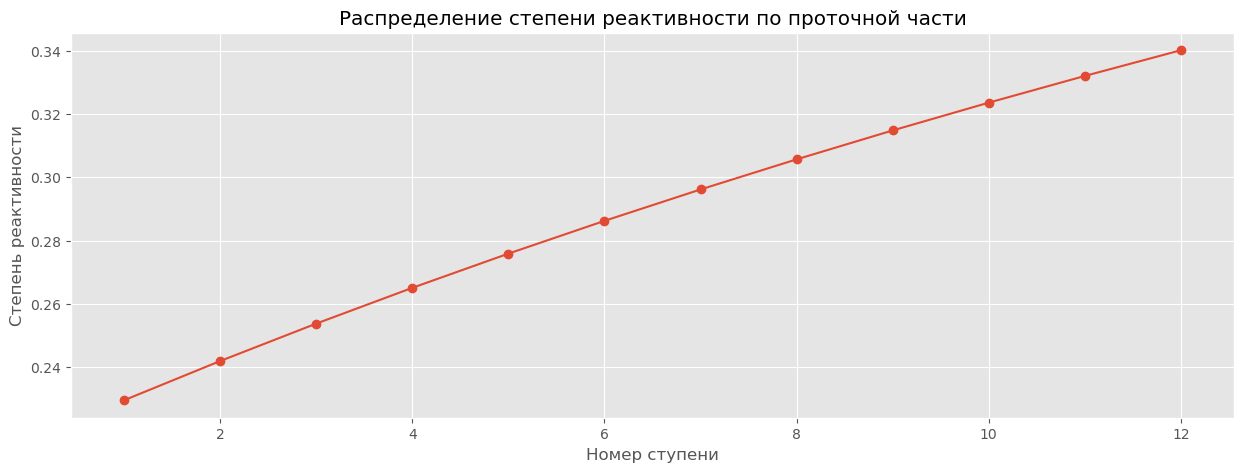

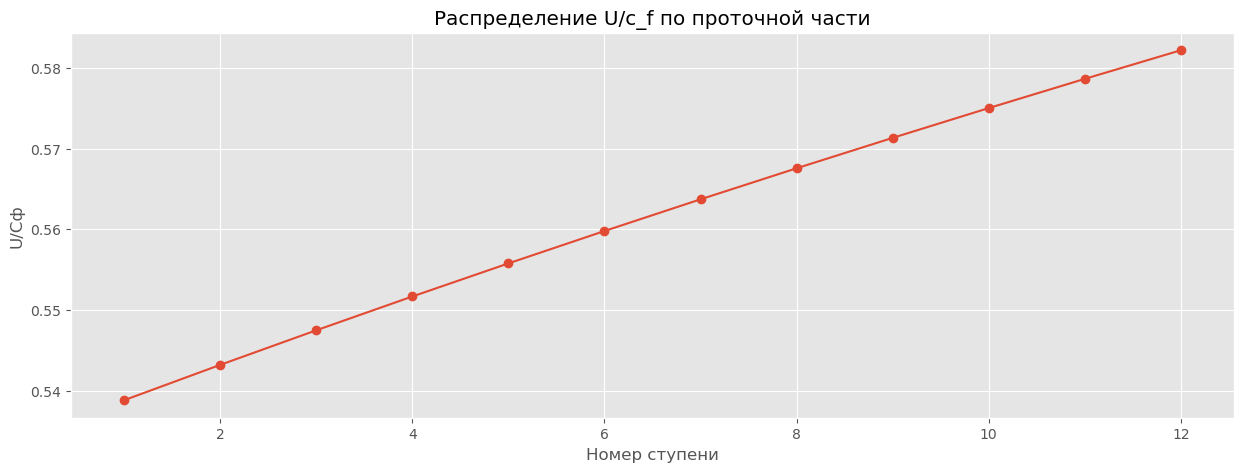

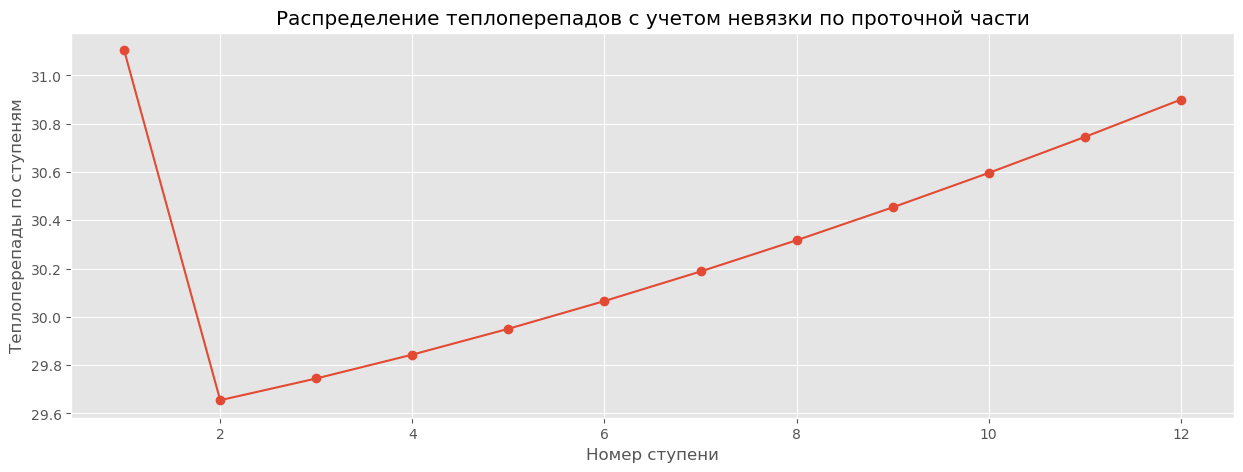

In [109]:
splitting = steps.SBS(
    d=lop.d, 
    n=lop.n, 
    n_stages=12, 
    G_0=g0, 
    P_o=17.053919399995042,  
    h_o=3272.543621175134, 
    P_z=turbine.point_1_teor.find_p(), 
    fi=fi,
    alpha_1=lop.alpha_1_e, 
    ro=lop.ro, 
    mu=mu, 
    efficiency=0.85, 
    veernost_1=15.42
)

# расчеты
new_actual_heat_drop, daf = splitting.calc()

table_ver, tabl_step = splitting.table()

# графики
splitting.plot_charts()

In [92]:
table_ver

,Веерность
,
"Величина обратной веерности, задаваемая студентом",15.42
Величина расчитанной обратной веерности,15.42


In [93]:
tabl_step

,Число ступеней
,
"Величина числа ступеней, задаваемая студентом",12.0
Величина расчитанного числа ступеней,12.0
